In [ ]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

In [2]:
# loading the dataset
df = pd.read_csv("../datasets/Pt_Nanoparticle/Pt_nanoparticle_dataset.csv")

In [3]:
df

,ID,T,tau,time,N_total,N_bulk,N_surface,Volume,R_min,R_max,...,q6q6_S17,q6q6_S18,q6q6_S19,q6q6_S20,q6q6_S20+,Surf_defects_mol,Surf_micros_mol,Surf_facets_mol,Total_E,Formation_E
0,1,303,0.000025,1,1732,1129,603,2.420000e-26,15.1180,18.9872,...,0,0,0,0,0,0.0000,121.5956,267.1222,-9237.3055,756.3345
1,2,303,0.000025,2,1755,1150,605,2.450000e-26,15.3043,20.0506,...,0,0,0,0,0,0.6383,117.4488,266.1747,-9335.3608,790.9892
2,3,303,0.000025,3,4672,3456,1216,6.530000e-26,21.5357,27.5179,...,0,0,0,0,0,0.4796,84.8806,205.7275,-25287.5650,1669.8750
3,4,303,0.000025,4,6823,5122,1701,9.540000e-26,23.3351,35.9820,...,0,0,0,0,0,0.6567,87.3462,189.9616,-37049.1710,2319.5390
4,5,303,0.000025,5,10733,8349,2384,1.500000e-25,25.7149,40.8339,...,0,0,0,0,0,0.6262,83.9156,163.6563,-58602.2500,3327.1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,1296,673,0.000250,6,3303,2078,1225,4.620000e-26,9.3836,33.5346,...,0,0,0,0,0,1.3566,161.7773,252.3319,-17528.9180,1529.3920
1296,1297,673,0.000250,7,3690,2364,1326,5.160000e-26,10.2056,34.3654,...,0,0,0,0,0,1.2143,150.8821,249.8511,-19609.9810,1681.3190
1297,1298,673,0.000250,8,4099,2663,1436,5.730000e-26,9.8460,34.5833,...,0,0,0,0,0,0.0000,149.2185,242.9583,-21799.8280,1851.4020
1298,1299,673,0.000250,9,4482,2914,1568,6.270000e-26,10.7151,36.9595,...,0,0,0,0,0,0.2499,146.7148,244.6914,-23852.5130,2008.6270


In [4]:
df = df.drop(['ID'], axis=1)
print(df[df.duplicated(keep=False)])

       T  tau  time  N_total  N_bulk  N_surface        Volume    R_min  \
823  673  0.0    10     1163     639        524  1.630000e-26  12.5328   
824  673  0.0    10     1163     639        524  1.630000e-26  12.5328   

       R_max  R_diff  ...  q6q6_S17  q6q6_S18  q6q6_S19  q6q6_S20  q6q6_S20+  \
823  19.1271  6.5943  ...         0         0         0         0          0   
824  19.1271  6.5943  ...         0         0         0         0          0   

     Surf_defects_mol  Surf_micros_mol  Surf_facets_mol    Total_E  \
823               0.0         258.1445         246.5858 -6068.3946   
824               0.0         258.1445         246.5858 -6068.3946   

     Formation_E  
823     642.1154  
824     642.1154  

[2 rows x 187 columns]


In [5]:
df = df.drop_duplicates()
df

,T,tau,time,N_total,N_bulk,N_surface,Volume,R_min,R_max,R_diff,...,q6q6_S17,q6q6_S18,q6q6_S19,q6q6_S20,q6q6_S20+,Surf_defects_mol,Surf_micros_mol,Surf_facets_mol,Total_E,Formation_E
0,303,0.000025,1,1732,1129,603,2.420000e-26,15.1180,18.9872,3.8692,...,0,0,0,0,0,0.0000,121.5956,267.1222,-9237.3055,756.3345
1,303,0.000025,2,1755,1150,605,2.450000e-26,15.3043,20.0506,4.7463,...,0,0,0,0,0,0.6383,117.4488,266.1747,-9335.3608,790.9892
2,303,0.000025,3,4672,3456,1216,6.530000e-26,21.5357,27.5179,5.9822,...,0,0,0,0,0,0.4796,84.8806,205.7275,-25287.5650,1669.8750
3,303,0.000025,4,6823,5122,1701,9.540000e-26,23.3351,35.9820,12.6469,...,0,0,0,0,0,0.6567,87.3462,189.9616,-37049.1710,2319.5390
4,303,0.000025,5,10733,8349,2384,1.500000e-25,25.7149,40.8339,15.1190,...,0,0,0,0,0,0.6262,83.9156,163.6563,-58602.2500,3327.1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,673,0.000250,6,3303,2078,1225,4.620000e-26,9.3836,33.5346,24.1511,...,0,0,0,0,0,1.3566,161.7773,252.3319,-17528.9180,1529.3920
1296,673,0.000250,7,3690,2364,1326,5.160000e-26,10.2056,34.3654,24.1598,...,0,0,0,0,0,1.2143,150.8821,249.8511,-19609.9810,1681.3190
1297,673,0.000250,8,4099,2663,1436,5.730000e-26,9.8460,34.5833,24.7373,...,0,0,0,0,0,0.0000,149.2185,242.9583,-21799.8280,1851.4020
1298,673,0.000250,9,4482,2914,1568,6.270000e-26,10.7151,36.9595,26.2444,...,0,0,0,0,0,0.2499,146.7148,244.6914,-23852.5130,2008.6270


In [6]:
print(df[df.duplicated(keep=False)])

Empty DataFrame
Columns: [T, tau, time, N_total, N_bulk, N_surface, Volume, R_min, R_max, R_diff, R_avg, R_std, R_skew, R_kurt, S_100, S_111, S_110, S_311, Curve_1-10, Curve_11-20, Curve_21-30, Curve_31-40, Curve_41-50, Curve_51-60, Curve_61-70, Curve_71-80, Curve_81-90, Curve_91-100, Curve_101-110, Curve_111-120, Curve_121-130, Curve_131-140, Curve_141-150, Curve_151-160, Curve_161-170, Curve_171-180, Avg_total, Avg_bulk, Avg_surf, TCN_0, TCN_1, TCN_2, TCN_3, TCN_4, TCN_5, TCN_6, TCN_7, TCN_8, TCN_9, TCN_10, TCN_11, TCN_12, TCN_13, TCN_14, TCN_15, TCN_16, TCN_17, TCN_18, TCN_19, TCN_20, BCN_0, BCN_1, BCN_2, BCN_3, BCN_4, BCN_5, BCN_6, BCN_7, BCN_8, BCN_9, BCN_10, BCN_11, BCN_12, BCN_13, BCN_14, BCN_15, BCN_16, BCN_17, BCN_18, BCN_19, BCN_20, SCN_0, SCN_1, SCN_2, SCN_3, SCN_4, SCN_5, SCN_6, SCN_7, SCN_8, SCN_9, SCN_10, SCN_11, SCN_12, SCN_13, SCN_14, SCN_15, SCN_16, SCN_17, SCN_18, ...]
Index: []

[0 rows x 187 columns]


In [7]:
print(df.shape)

(1299, 187)


In [8]:
df2 = df.groupby(['T']).size().reset_index().rename(columns={0:'count'})

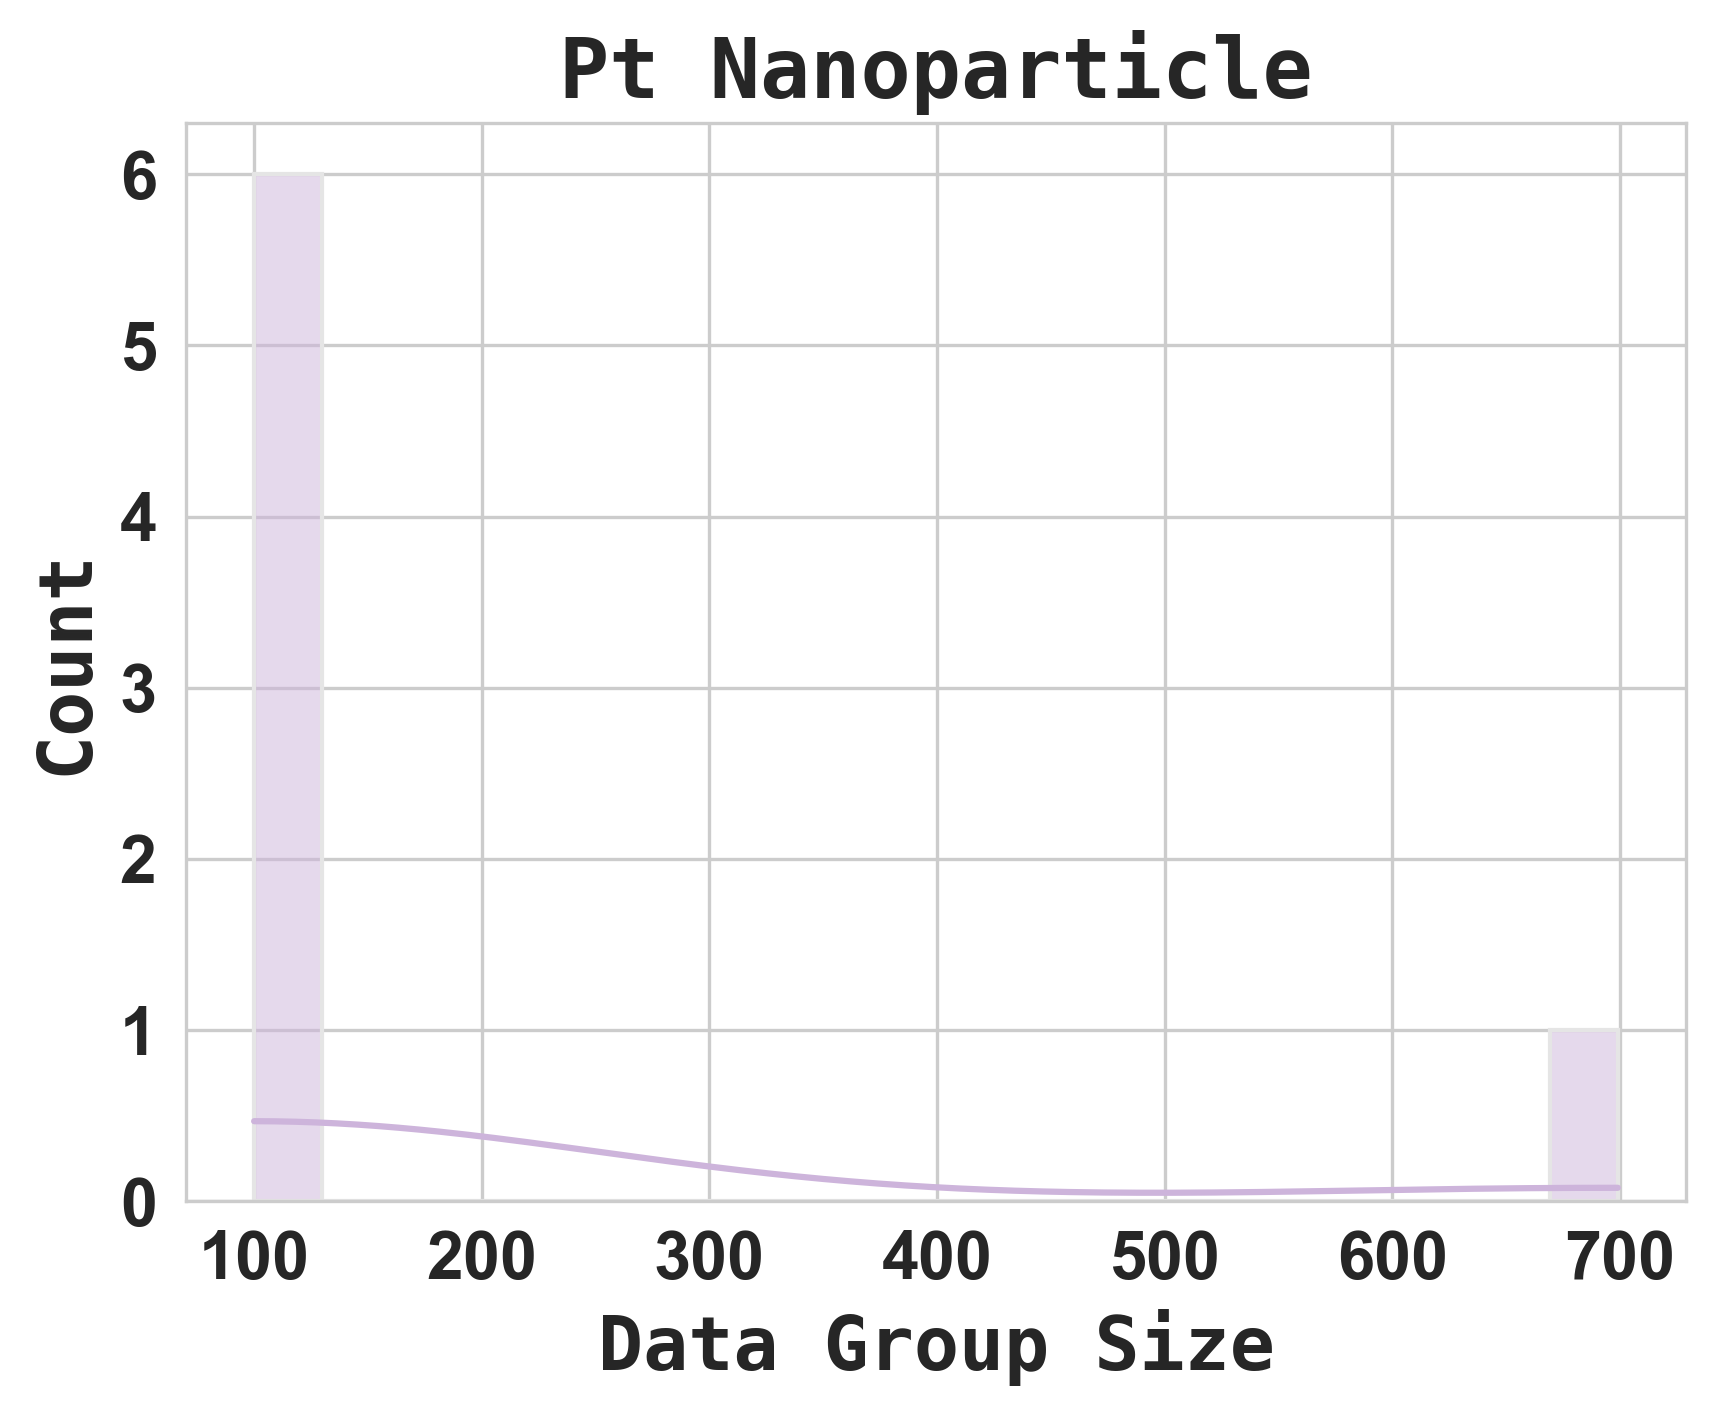

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create the plot
font = {'family': 'monospace', 'size': 16, 'weight':'bold'}
plt.rc('font', **font)
plt.rcParams['font.family'] = 'monospace'

sns.set_style("whitegrid")
plt.figure(figsize=(6, 5), dpi=300)

sns.histplot(data=df2, x='count', kde=True, color='#cdb4db', edgecolor='#e5e5e5',bins=20)

plt.title('Pt Nanoparticle', fontsize=20, fontname="monospace",weight='bold')
plt.xlabel('Data Group Size', fontsize=18, fontname="monospace", weight='bold')
plt.ylabel('Count', fontsize=18, fontname="monospace", weight='bold')

# Show the plot
plt.tight_layout()
plt.savefig('Pt_hist.png',
               bbox_inches="tight",
               pad_inches=0.05)
plt.show()

In [10]:
df_subset = df.drop(['Total_E', 'Formation_E', 'Surf_defects_mol', 'Surf_micros_mol', 'Surf_facets_mol'], axis=1)
df_subset

,T,tau,time,N_total,N_bulk,N_surface,Volume,R_min,R_max,R_diff,...,q6q6_S12,q6q6_S13,q6q6_S14,q6q6_S15,q6q6_S16,q6q6_S17,q6q6_S18,q6q6_S19,q6q6_S20,q6q6_S20+
0,303,0.000025,1,1732,1129,603,2.420000e-26,15.1180,18.9872,3.8692,...,0,0,0,0,0,0,0,0,0,0
1,303,0.000025,2,1755,1150,605,2.450000e-26,15.3043,20.0506,4.7463,...,0,0,0,0,0,0,0,0,0,0
2,303,0.000025,3,4672,3456,1216,6.530000e-26,21.5357,27.5179,5.9822,...,0,0,0,0,0,0,0,0,0,0
3,303,0.000025,4,6823,5122,1701,9.540000e-26,23.3351,35.9820,12.6469,...,1,0,0,0,0,0,0,0,0,0
4,303,0.000025,5,10733,8349,2384,1.500000e-25,25.7149,40.8339,15.1190,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,673,0.000250,6,3303,2078,1225,4.620000e-26,9.3836,33.5346,24.1511,...,0,0,0,0,0,0,0,0,0,0
1296,673,0.000250,7,3690,2364,1326,5.160000e-26,10.2056,34.3654,24.1598,...,0,0,0,0,0,0,0,0,0,0
1297,673,0.000250,8,4099,2663,1436,5.730000e-26,9.8460,34.5833,24.7373,...,0,0,0,0,0,0,0,0,0,0
1298,673,0.000250,9,4482,2914,1568,6.270000e-26,10.7151,36.9595,26.2444,...,0,0,0,0,0,0,0,0,0,0


In [11]:
seed_split = np.load(file="../seed_for_dataSplit.npy")
seed_inital = np.load(file="../seed_for_initialSamples.npy")
seed_model = np.load(file="../seed_for_model.npy")

In [12]:
data = df_subset
labels_true = df[['Formation_E']]

for i in range(20):
    X_train, X_test, y_train, y_test = train_test_split(data, labels_true, test_size=0.3, random_state=seed_split[i])
    scaler = preprocessing.StandardScaler()
    X_train[X_train.columns] = scaler.fit_transform(X_train[X_train.columns])
    X_test[X_test.columns] = scaler.transform(X_test[X_test.columns])
    
    X_train.to_csv("../datasets/Pt_Nanoparticle//split_data//X_train" + str(i) +".csv", encoding='utf-8', index=False)
    X_test.to_csv("../datasets/Pt_Nanoparticle//split_data//X_test" + str(i) +".csv", encoding='utf-8', index=False)
    y_train.to_csv("../datasets/Pt_Nanoparticle//split_data//y_train" + str(i) +".csv", encoding='utf-8', index=False)
    y_test.to_csv("../datasets/Pt_Nanoparticle//split_data//y_test" + str(i) +".csv", encoding='utf-8', index=False)